In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os
import sys
from pathlib import Path

In [2]:
library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

from survival.agreement import (
    sign_test, intraclass_correlation, bland_altman_group_analysis
)

DATA_PATH = library_path.parent / 'data'
PLOTS_PATH = library_path.parent / 'plots'

In [3]:
df = pd.read_csv(f"{DATA_PATH}/all_data.csv", sep="\t")
df = df[["sPCI", "pPCI", "Sex", "Age", "Tumor"]].copy()
df = df.dropna(subset=["sPCI", "pPCI"])

print(f"n = {len(df)}")
print(f"\nSex counts:\n{df['Sex'].value_counts().sort_index()}")
print(f"\nTumour type counts:\n{df['Tumor'].value_counts().sort_index()}")
print(f"\nAge: min={df['Age'].min():.0f}, median={df['Age'].median():.0f}, max={df['Age'].max():.0f}")
print(f"Age < 60: n={( df['Age'] < 60).sum()},  Age \u2265 60: n={(df['Age'] >= 60).sum()}")

n = 454

Sex counts:
Sex
1    167
2    287
Name: count, dtype: int64

Tumour type counts:
Tumor
1     122
2      20
3      27
4      74
5      89
6      52
7      28
8      11
9       8
10      1
11      3
13      4
15      1
16      5
17      3
18      5
19      1
Name: count, dtype: int64

Age: min=17, median=54, max=79
Age < 60: n=297,  Age ≥ 60: n=157


In [4]:
# Group columns used by the Level-2 analysis
df["SexGroup"] = df["Sex"].map({1: "Sex=1", 2: "Sex=2"})
df["AgeGroup"] = np.where(df["Age"] < 60, "Age<60", "Age≥60")

def _tumour_group(t):
    if t in [1, 2]: return "Colorectal"
    if t in [3, 5]: return "Appendiceal"
    if t == 4:      return "Ovarian"
    if t == 6:      return "Gastric"
    if t == 7:      return "Mesothelioma"
    return "Other"

df["TumourGroup"] = df["Tumor"].apply(_tumour_group)

In [5]:
def analyze_subgroup(sPCI_vals, pPCI_vals, label=""):
    """Bland-Altman summary statistics for a subgroup."""
    s = np.asarray(sPCI_vals, dtype=float)
    p = np.asarray(pPCI_vals, dtype=float)
    mask = ~(np.isnan(s) | np.isnan(p))
    s, p = s[mask], p[mask]
    n = len(s)

    diff = s - p
    mean_vals = (s + p) / 2
    mean_bias = float(np.mean(diff))
    median_bias = float(np.median(diff))
    sd_diff = float(np.std(diff, ddof=1))
    loa_upper = mean_bias + 1.96 * sd_diff
    loa_lower = mean_bias - 1.96 * sd_diff
    slope_b, intercept_b, r_b, p_b, _ = linregress(mean_vals, diff)
    n_pos, n_nonzero, p_sign = sign_test(s, p)

    try:
        icc_row = intraclass_correlation(s, p)
        icc_val = float(icc_row["ICC"])
        icc_ci = icc_row["CI95"]
    except Exception:
        icc_val, icc_ci = float("nan"), [float("nan"), float("nan")]

    return {
        "label": label, "n": n,
        "mean_bias": mean_bias, "median_bias": median_bias,
        "sd_diff": sd_diff, "loa_lower": loa_lower, "loa_upper": loa_upper,
        "slope": float(slope_b), "intercept": float(intercept_b),
        "r": float(r_b), "p_prop": float(p_b),
        "sign_pos": n_pos, "sign_n": n_nonzero, "sign_p": p_sign,
        "icc": icc_val, "icc_ci": icc_ci,
    }


def print_result(res):
    print(f"\n{'='*50}")
    print(f"  {res['label']}  (n={res['n']})")
    print(f"{'='*50}")
    print(f"  Mean bias:    {res['mean_bias']:.3f}")
    print(f"  Median bias:  {res['median_bias']:.3f}")
    print(f"  SD:           {res['sd_diff']:.3f}")
    print(f"  LoA:          [{res['loa_lower']:.2f},  {res['loa_upper']:.2f}]")
    print(f"  Prop. bias:   slope={res['slope']:.3f},  r={res['r']:.3f},  p={res['p_prop']:.3e}")
    print(f"  Sign test:    {res['sign_pos']}/{res['sign_n']},  p={res['sign_p']:.3e}")
    print(f"  ICC(A,1):     {res['icc']:.3f}  95% CI: {res['icc_ci']}")


def ba_panel(ax, sPCI_vals, pPCI_vals, label, color="steelblue"):
    """Bland-Altman panel (classical LoA + proportional bias regression line)."""
    s = np.asarray(sPCI_vals, dtype=float)
    p = np.asarray(pPCI_vals, dtype=float)
    mask = ~(np.isnan(s) | np.isnan(p))
    s, p = s[mask], p[mask]

    diff = s - p
    mean_vals = (s + p) / 2
    mean_bias = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    loa_upper = mean_bias + 1.96 * sd_diff
    loa_lower = mean_bias - 1.96 * sd_diff
    slope_b, intercept_b, *_ = linregress(mean_vals, diff)
    x_line = np.linspace(mean_vals.min(), mean_vals.max(), 200)

    ax.scatter(mean_vals, diff, color=color, edgecolors="white", s=45, alpha=0.75, zorder=3)
    ax.axhline(mean_bias, color="black", linewidth=1.4, label=f"Bias: {mean_bias:.2f}")
    ax.axhline(loa_upper, color="crimson", linestyle="--", linewidth=1.0,
               label=f"LoA: [{loa_lower:.1f}, {loa_upper:.1f}]")
    ax.axhline(loa_lower, color="crimson", linestyle="--", linewidth=1.0, label="_")
    ax.plot(x_line, intercept_b + slope_b * x_line, color="darkorange", linewidth=1.0,
            label=f"Slope: {slope_b:.3f}")
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.9)
    ax.fill_between([mean_vals.min(), mean_vals.max()],
                    loa_lower, loa_upper, alpha=0.05, color="crimson")
    ax.set_title(f"{label}  (n={len(s)})", fontsize=10)
    ax.set_xlabel("Mean of sPCI and pPCI", fontsize=8)
    ax.set_ylabel("Difference (sPCI \u2212 pPCI)", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")

## 1. Bland-Altman by Sex

Sex coding in the raw data: 1 and 2.  Verify against the data dictionary before reporting.


  Male  (n=167)
  Mean bias:    7.545
  Median bias:  5.000
  SD:           7.266
  LoA:          [-6.70,  21.79]
  Prop. bias:   slope=0.472,  r=0.498,  p=7.443e-12
  Sign test:    144/159,  p=1.238e-27
  ICC(A,1):     0.455  95% CI: [-0.02  0.71]



  Female  (n=287)
  Mean bias:    6.592
  Median bias:  5.000
  SD:           6.601
  LoA:          [-6.35,  19.53]
  Prop. bias:   slope=0.496,  r=0.519,  p=3.199e-21
  Sign test:    255/270,  p=1.702e-57
  ICC(A,1):     0.459  95% CI: [0.  0.7]


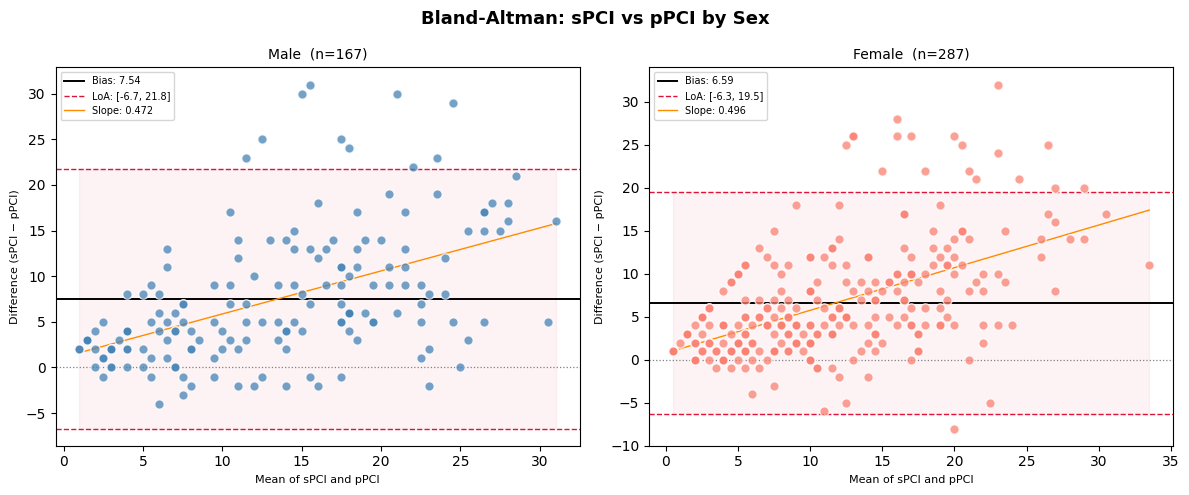

In [6]:
sex_groups = [
    (1, "Male", "steelblue"),
    (2, "Female", "salmon"),
]

sex_results = []
for sex_val, label, color in sex_groups:
    sub = df[df["Sex"] == sex_val]
    res = analyze_subgroup(sub["sPCI"], sub["pPCI"], label)
    sex_results.append((sex_val, label, color, res))
    print_result(res)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
axes = axes.flatten()
for ax, (sex_val, label, color, _) in zip(axes, sex_results):
    sub = df[df["Sex"] == sex_val]
    ba_panel(ax, sub["sPCI"], sub["pPCI"], label, color=color)
plt.suptitle("Bland-Altman: sPCI vs pPCI by Sex", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "bland_altman_subgroups_sex.png", dpi=600)
plt.show()

In [7]:
res_sex = bland_altman_group_analysis(df, "sPCI", "pPCI", "SexGroup")

────────────────────────────────────────────────────────────
BLAND-ALTMAN GROUP ANALYSIS  [SexGroup]
────────────────────────────────────────────────────────────

[2a] BIAS DIFFERENCES ACROSS GROUPS
     d ~ C(SexGroup),  overall p = 0.1539  (not significant)

     Group-level bias (95 % CI):
         n   bias  ci_bias_lower  ci_bias_upper
group                                          
Sex=1  167  7.545          6.435          8.655
Sex=2  287  6.592          5.825          7.359

[2b] VARIANCE DIFFERENCES ACROSS GROUPS
     Levene   W = 1.8313,  p = 0.1767  (not significant)
     Bartlett K = 1.9576,  p = 0.1618  (not significant)

     Group-level SD:
         n     sd     var
group                    
Sex=2  287  6.601  43.578
Sex=1  167  7.266  52.792

GROUP-SPECIFIC LoA  (alpha = 0.05)
         n  bias  ci_bias_lower  ci_bias_upper    sd  loa_upper  ci_loa_upper_lo  ci_loa_upper_hi  loa_lower  ci_loa_lower_lo  ci_loa_lower_hi
group                                                 

## 2. Bland-Altman by Age Group

Split at 60 years (median age in this cohort is 54; the 60-year threshold follows clinical convention).


  Age < 60  (n=297)
  Mean bias:    7.276
  Median bias:  5.000
  SD:           6.527
  LoA:          [-5.52,  20.07]
  Prop. bias:   slope=0.491,  r=0.541,  p=5.300e-24
  Sign test:    269/280,  p=1.827e-65
  ICC(A,1):     0.462  95% CI: [-0.04  0.72]

  Age ≥ 60  (n=157)
  Mean bias:    6.312
  Median bias:  4.000
  SD:           7.432
  LoA:          [-8.25,  20.88]
  Prop. bias:   slope=0.478,  r=0.475,  p=3.150e-10
  Sign test:    130/149,  p=1.585e-21
  ICC(A,1):     0.462  95% CI: [0.07 0.68]


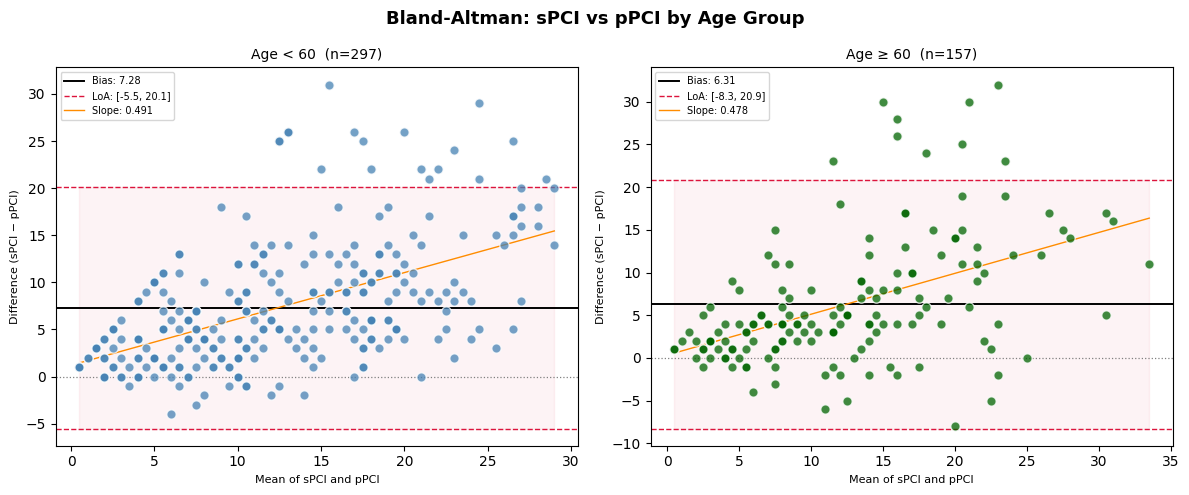

In [8]:
age_groups = [
    (df["Age"] < 60,  "Age < 60",       "steelblue"),
    (df["Age"] >= 60, "Age \u2265 60",  "darkgreen"),
]

age_results = []
for mask, label, color in age_groups:
    sub = df[mask]
    res = analyze_subgroup(sub["sPCI"], sub["pPCI"], label)
    age_results.append((mask, label, color, res))
    print_result(res)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
axes = axes.flatten()
for ax, (mask, label, color, _) in zip(axes, age_results):
    sub = df[mask]
    ba_panel(ax, sub["sPCI"], sub["pPCI"], label, color=color)
plt.suptitle("Bland-Altman: sPCI vs pPCI by Age Group", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "bland_altman_subgroups_age.png", dpi=600)
plt.show()

In [9]:
res_age = bland_altman_group_analysis(df, "sPCI", "pPCI", "AgeGroup")

────────────────────────────────────────────────────────────
BLAND-ALTMAN GROUP ANALYSIS  [AgeGroup]
────────────────────────────────────────────────────────────

[2a] BIAS DIFFERENCES ACROSS GROUPS
     d ~ C(AgeGroup),  overall p = 0.1547  (not significant)

     Group-level bias (95 % CI):
          n   bias  ci_bias_lower  ci_bias_upper
group                                           
Age<60  297  7.276          6.531          8.021
Age≥60  157  6.312          5.141          7.484

[2b] VARIANCE DIFFERENCES ACROSS GROUPS
     Levene   W = 0.4757,  p = 0.4907  (not significant)
     Bartlett K = 3.5154,  p = 0.0608  (not significant)

     Group-level SD:
          n     sd     var
group                     
Age<60  297  6.527  42.606
Age≥60  157  7.432  55.229

GROUP-SPECIFIC LoA  (alpha = 0.05)
          n  bias  ci_bias_lower  ci_bias_upper    sd  loa_upper  ci_loa_upper_lo  ci_loa_upper_hi  loa_lower  ci_loa_lower_lo  ci_loa_lower_hi
group                                        

## 3. Bland-Altman by Tumour Type

Groups:
- **Colorectal** — types 1 + 2
- **Appendiceal neoplasms** — types 3 + 5
- **Ovarian** — type 4
- **Gastric** — type 6
- **Mesothelioma** — type 7
- **Other** — types 8 and above


  Colorectal  (n=142)
  Mean bias:    4.901
  Median bias:  4.000
  SD:           4.726
  LoA:          [-4.36,  14.16]
  Prop. bias:   slope=0.339,  r=0.486,  p=8.797e-10
  Sign test:    118/132,  p=1.138e-21
  ICC(A,1):     0.636  95% CI: [0.06 0.84]



  Appendiceal neoplasms  (n=116)
  Mean bias:    10.741
  Median bias:  9.000
  SD:           8.335
  LoA:          [-5.60,  27.08]
  Prop. bias:   slope=0.470,  r=0.463,  p=1.701e-07
  Sign test:    111/114,  p=2.379e-29
  ICC(A,1):     0.352  95% CI: [-0.09  0.65]

  Ovarian  (n=74)
  Mean bias:    5.878
  Median bias:  4.500
  SD:           6.713
  LoA:          [-7.28,  19.04]
  Prop. bias:   slope=0.482,  r=0.521,  p=1.946e-06
  Sign test:    60/67,  p=1.328e-11
  ICC(A,1):     0.512  95% CI: [0.07 0.74]

  Gastric  (n=52)
  Mean bias:    4.500
  Median bias:  3.000
  SD:           4.697
  LoA:          [-4.71,  13.71]
  Prop. bias:   slope=0.593,  r=0.604,  p=2.165e-06
  Sign test:    45/48,  p=1.313e-10
  ICC(A,1):     0.453  95% CI: [-0.01  0.72]



  Mesothelioma  (n=28)
  Mean bias:    11.143
  Median bias:  12.500
  SD:           7.281
  LoA:          [-3.13,  25.41]
  Prop. bias:   slope=0.730,  r=0.662,  p=1.257e-04
  Sign test:    27/28,  p=2.161e-07
  ICC(A,1):     0.257  95% CI: [-0.1  0.6]

  Other (type ≥ 8)  (n=42)
  Mean bias:    5.452
  Median bias:  4.000
  SD:           5.157
  LoA:          [-4.66,  15.56]
  Prop. bias:   slope=0.507,  r=0.614,  p=1.535e-05
  Sign test:    38/40,  p=1.493e-09
  ICC(A,1):     0.537  95% CI: [-0.02  0.79]


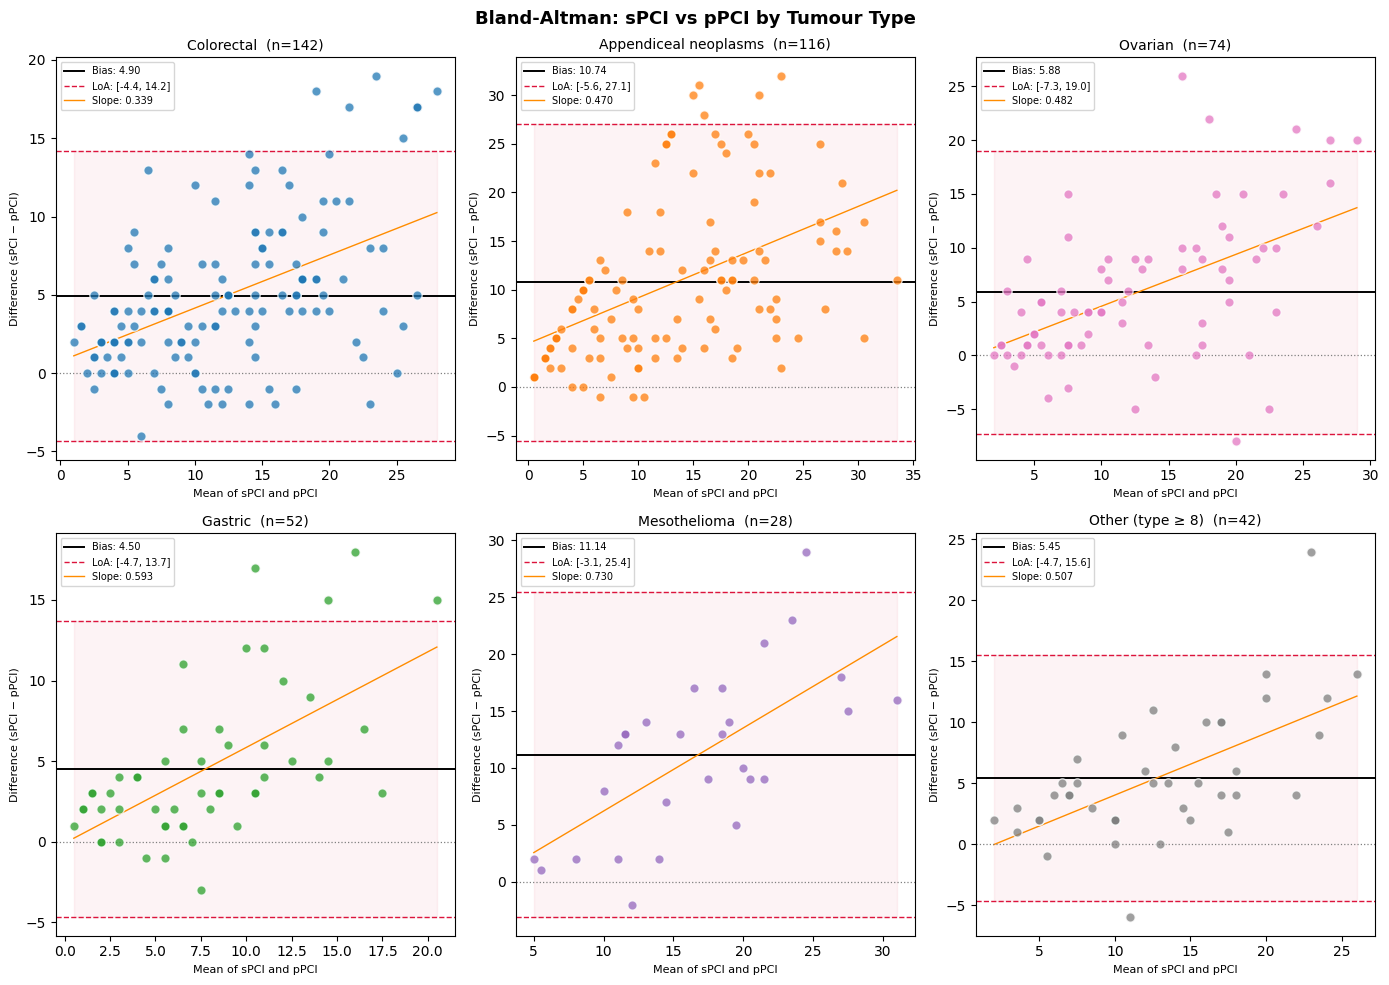

In [10]:
tumor_groups = [
    (df["Tumor"].isin([1, 2]), "Colorectal",            "tab:blue"),
    (df["Tumor"].isin([3, 5]), "Appendiceal neoplasms", "tab:orange"),
    (df["Tumor"] == 4,         "Ovarian",               "tab:pink"),
    (df["Tumor"] == 6,         "Gastric",               "tab:green"),
    (df["Tumor"] == 7,         "Mesothelioma",          "tab:purple"),
    (df["Tumor"] >= 8,         "Other (type ≥ 8)",      "tab:gray"),
]

tumor_results = []
for mask, label, color in tumor_groups:
    sub = df[mask]
    res = analyze_subgroup(sub["sPCI"], sub["pPCI"], label)
    tumor_results.append((mask, label, color, res))
    print_result(res)

ncols = 3
nrows = max(1, (len(tumor_groups) + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), squeeze=False)
axes = axes.flatten()
for i, (mask, label, color, _) in enumerate(tumor_results):
    sub = df[mask]
    ba_panel(axes[i], sub["sPCI"], sub["pPCI"], label, color=color)
for j in range(len(tumor_results), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Bland-Altman: sPCI vs pPCI by Tumour Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "bland_altman_subgroups_tumor.png", dpi=600)
plt.show()

In [11]:
res_tumour = bland_altman_group_analysis(df, "sPCI", "pPCI", "TumourGroup")

────────────────────────────────────────────────────────────
BLAND-ALTMAN GROUP ANALYSIS  [TumourGroup]
────────────────────────────────────────────────────────────

[2a] BIAS DIFFERENCES ACROSS GROUPS
     d ~ C(TumourGroup),  overall p = 0.0000  *** significant

     Group-level bias (95 % CI):
                n    bias  ci_bias_lower  ci_bias_upper
group                                                  
Appendiceal   116  10.741          9.208         12.274
Colorectal    142   4.901          4.117          5.685
Gastric        52   4.500          3.192          5.808
Mesothelioma   28  11.143          8.320         13.966
Other          42   5.452          3.845          7.059
Ovarian        74   5.878          4.323          7.434

[2b] VARIANCE DIFFERENCES ACROSS GROUPS
     Levene   W = 8.7688,  p = 0.0000  *** significant
     Bartlett K = 52.9579,  p = 0.0000  *** significant

     Group-level SD:
                n     sd     var
group                           
Colorectal    

## 4. Summary Table

In [12]:
all_results = (
    [res for _, _, _, res in sex_results]
    + [res for _, _, _, res in age_results]
    + [res for _, _, _, res in tumor_results]
)

summary_df = pd.DataFrame([{
    "Subgroup":    r["label"],
    "n":           r["n"],
    "Mean bias":   round(r["mean_bias"],   2),
    "Median bias": round(r["median_bias"], 2),
    "SD":          round(r["sd_diff"],     2),
    "LoA lower":   round(r["loa_lower"],   2),
    "LoA upper":   round(r["loa_upper"],   2),
    "Prop. slope": round(r["slope"],       3),
    "Prop. p":     f"{r['p_prop']:.2e}",
    "Sign p":      f"{r['sign_p']:.2e}",
    "ICC(A,1)":    round(r["icc"],         3),
} for r in all_results])

pd.set_option("display.max_rows", 30)
summary_df

,Subgroup,n,Mean bias,Median bias,SD,LoA lower,LoA upper,Prop. slope,Prop. p,Sign p,"ICC(A,1)"
0,Male,167,7.54,5.0,7.27,-6.70,21.79,0.472,7.44e-12,1.24e-27,0.455
1,Female,287,6.59,5.0,6.60,-6.35,19.53,0.496,3.20e-21,1.70e-57,0.459
2,Age < 60,297,7.28,5.0,6.53,-5.52,20.07,0.491,5.30e-24,1.83e-65,0.462
3,Age ≥ 60,157,6.31,4.0,7.43,-8.25,20.88,0.478,3.15e-10,1.58e-21,0.462
4,Colorectal,142,4.90,4.0,4.73,-4.36,14.16,0.339,8.80e-10,1.14e-21,0.636
5,Appendiceal neoplasms,116,10.74,9.0,8.34,-5.60,27.08,0.470,1.70e-07,2.38e-29,0.352
6,Ovarian,74,5.88,4.5,6.71,-7.28,19.04,0.482,1.95e-06,1.33e-11,0.512
7,Gastric,52,4.50,3.0,4.70,-4.71,13.71,0.593,2.17e-06,1.31e-10,0.453
8,Mesothelioma,28,11.14,12.5,7.28,-3.13,25.41,0.730,1.26e-04,2.16e-07,0.257
9,Other (type ≥ 8),42,5.45,4.0,5.16,-4.66,15.56,0.507,1.54e-05,1.49e-09,0.537
